    events_train.csv - данные о действиях, которые совершают студенты со стэпами

step_id - id стэпа

user_id - анонимизированный id юзера

timestamp - время наступления события в формате unix date

action - событие, возможные значения: 

discovered - пользователь перешел на стэп

viewed - просмотр шага,

started_attempt - начало попытки решить шаг, ранее нужно было явно нажать на кнопку - начать решение, перед тем как приступить к решению практического шага

passed - удачное решение практического шага

    submissions_train.csv - данные о времени и статусах сабмитов к практическим заданиям

step_id - id стэпа

timestamp - время отправки решения в формате unix date

submission_status - статус решения

user_id - анонимизированный id юзера

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [2]:
sns.set(rc={'figure.figsize':(9,6)})

In [3]:
event_data = pd.read_csv('event_data_train.csv')

In [4]:
submissions_data = pd.read_csv('submissions_data_train.csv')

In [5]:
event_data.head(10)

,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632
5,32811,1434340895,passed,17632
6,32929,1434340921,discovered,17632
7,32929,1434340921,viewed,17632
8,32929,1434340939,started_attempt,17632
9,32929,1434340944,passed,17632


In [6]:
submissions_data.head(10)

,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853
5,31976,1434348188,correct,15853
6,31976,1478852055,correct,15853
7,31977,1434347371,correct,15853
8,31978,1434349981,correct,15853
9,31979,1434446091,correct,15853


In [7]:
event_data['action'].unique()

array(['viewed', 'passed', 'discovered', 'started_attempt'], dtype=object)

In [8]:
event_data['date'] = pd.to_datetime(event_data['timestamp'], unit='s')

In [9]:
event_data['date'].min()

Timestamp('2015-06-15 04:00:48')

In [10]:
event_data['date'].max()

Timestamp('2018-05-19 23:33:31')

In [11]:
event_data['day'] = event_data['date'].dt.date

In [12]:
submissions_data['date'] = pd.to_datetime(submissions_data['timestamp'], unit='s')
submissions_data['day'] = submissions_data['date'].dt.date

<Axes: xlabel='day'>

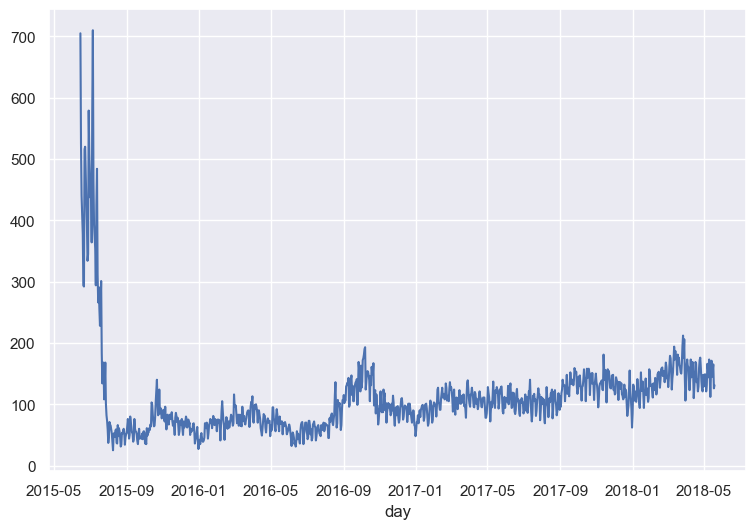

In [13]:
event_data.groupby('day')['user_id'].nunique().plot()

<Axes: >

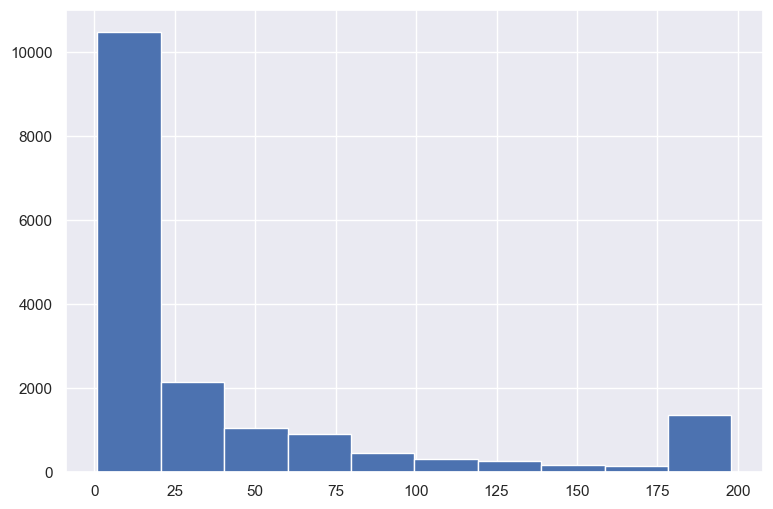

In [14]:
event_data[event_data['action'] == 'passed'] \
    .groupby('user_id', as_index=False)['step_id'].count() \
    .rename(columns={'step_id': 'passed_steps'})['passed_steps'].hist()
# неправильно. не учтены юзеры, у кторых 0 'passed_steps', т.е. они не решили успешно ни одного степа

In [15]:
users_events_data = event_data.pivot_table(index='user_id', columns='action', values='step_id', aggfunc='count', fill_value=0) \
          .reset_index()

<Axes: >

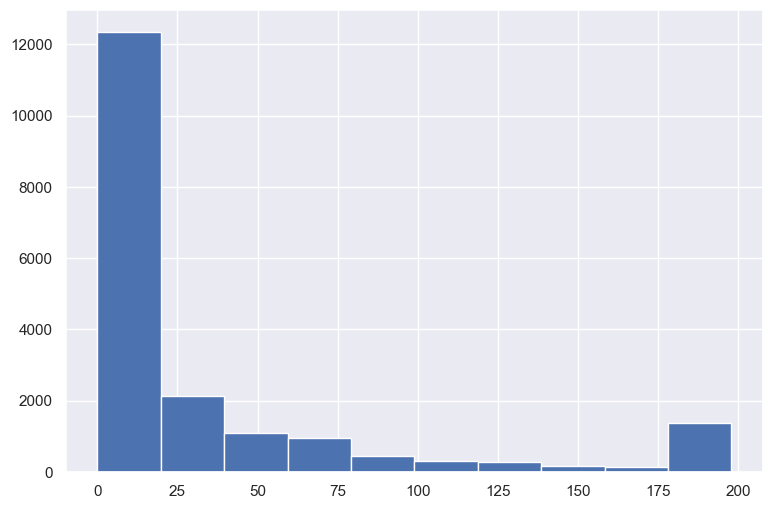

In [16]:
users_events_data['passed'].hist()

In [17]:
users_scores = submissions_data.pivot_table(index='user_id', 
                                           columns='submission_status', 
                                           values='step_id', 
                                           aggfunc='count', fill_value=0).reset_index()

In [18]:
users_scores.head()

submission_status,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


Посмотрим, какие перерывы характерны для пользователей

In [19]:
# отберем для каждого пользователя дни, когда он был активен(без повторений)
gap_data = event_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']) \
    .groupby('user_id')['timestamp'].apply(list) \
    .apply(np.diff).values

In [20]:
gap_data = pd.Series(np.concatenate(gap_data, axis=0))

In [21]:
gap_data = gap_data / (24 * 60 * 60)
# разницы в днях перерывов, которые наблюдались у пользователей

<Axes: >

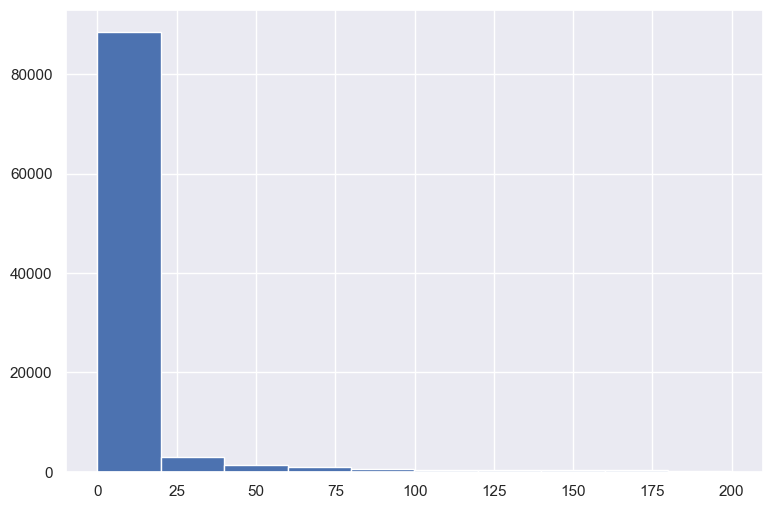

In [22]:
gap_data[gap_data < 200].hist()

In [23]:
gap_data.quantile(0.95)

59.760440972222156

In [24]:
gap_data.quantile(0.90)

18.325995370370403

Возьмем 30 дней перерыва для того, чтобы сказать, что студент не вернется на курс

In [25]:
event_data.tail()

,step_id,timestamp,action,user_id,date,day
3480698,33375,1526772685,viewed,11677,2018-05-19 23:31:25,2018-05-19
3480699,32815,1526772750,viewed,5198,2018-05-19 23:32:30,2018-05-19
3480700,32815,1526772750,discovered,5198,2018-05-19 23:32:30,2018-05-19
3480701,32815,1526772750,passed,5198,2018-05-19 23:32:30,2018-05-19
3480702,33892,1526772811,viewed,18526,2018-05-19 23:33:31,2018-05-19


In [26]:
users_data = event_data.groupby('user_id',as_index=False) \
    .agg({'timestamp': 'max'}).rename(columns={'timestamp': 'last_timestamp'})

In [27]:
now = 1526772811
drop_out_threshold = 60 * 60 * 24 * 30 # 1 месяц

In [28]:
users_data['is_gone_user'] = (now - users_data['last_timestamp']) > drop_out_threshold
# в скобках показывает, сколько прошло секунд с последнего действия до 2018-05-19. True - прошло больше месяца

In [29]:
users_data = users_data.merge(users_scores, on='user_id', how='outer')

In [30]:
users_data = users_data.fillna(0)

In [31]:
users_data = users_data.merge(users_events_data, on='user_id', how='outer')

In [32]:
users_days = event_data.groupby('user_id')['day'].nunique().to_frame().reset_index()

In [33]:
users_data = users_data.merge(users_days, on='user_id', how='outer')

In [34]:
user_min_time = event_data.groupby('user_id', as_index=False).agg({'timestamp': 'min'}) \
    .rename({'timestamp': 'min_timestamp'}, axis=1)

In [35]:
users_data = users_data.merge(user_min_time, how='outer')

Проверим, не потерялись ли данные в процессе обработки

In [36]:
users_data['user_id'].nunique()

19234

In [37]:
event_data['user_id'].nunique()

19234

In [38]:
# добавим колонку, закончил ли студент курс(набрал минимум 170 баллов)
users_data['pased_course'] = users_data['passed'] > 170

In [39]:
users_data.groupby('pased_course').count()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day,min_timestamp
pased_course,,,,,,,,,,,
False,17809,17809,17809,17809,17809,17809,17809,17809,17809,17809,17809
True,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425


In [40]:
 100 * 1425 / 17809

8.001572238755685

Курс прошли примерно 8% студентов

In [41]:
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day,min_timestamp,pased_course
0,1,1472827464,True,0.0,0.0,1,0,0,1,1,1472827464,False
1,2,1519226966,True,2.0,0.0,9,9,2,10,2,1514383364,False
2,3,1444581588,True,29.0,23.0,91,87,30,192,7,1434358476,False
3,5,1499859939,True,2.0,2.0,11,11,4,12,2,1466156809,False
4,7,1521634660,True,0.0,0.0,1,1,0,1,1,1521634660,False


In [42]:
# сколько уникальных дней пользователь потратил на обучение
users_data[users_data['pased_course'] == True]['day'].median()

20.0

<Axes: >

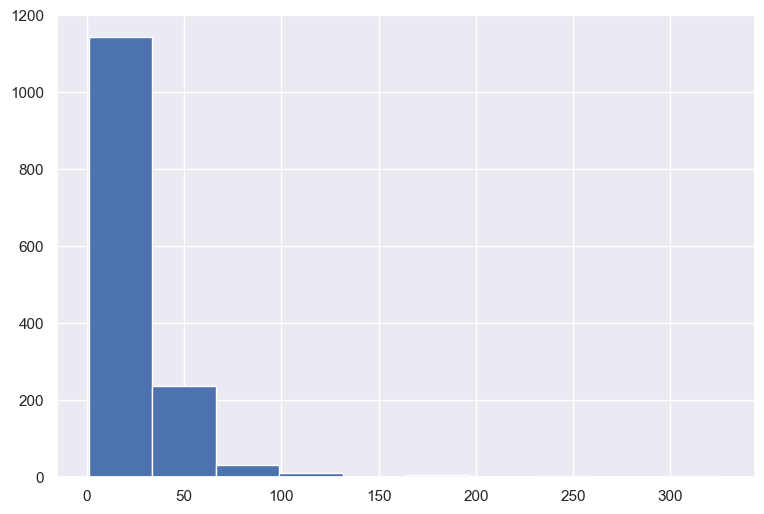

In [43]:
users_data[users_data['pased_course'] == True]['day'].hist()

In [44]:
event_data.head()

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


In [45]:
# нужно отобрать события от первого контакта юзера с курсом до 3х дней
threshhold_timestamp = 3 * 24 * 60 * 60

In [46]:
users_data['threshhold_timestamp'] = users_data['min_timestamp'] + threshhold_timestamp

In [47]:
event_data = event_data.merge(users_data[['user_id', 'threshhold_timestamp']], how='outer')

In [48]:
event_data_train = event_data[event_data['timestamp'] <= event_data['threshhold_timestamp']]

In [49]:
event_data_train.head()

,step_id,timestamp,action,user_id,date,day,threshhold_timestamp
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,1434600048
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,1434600048
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,1434600048
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,1434600048
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,1434600048


In [50]:
# проверим качество отбора
event_data_train.groupby('user_id')['day'].nunique().max()
# всё отлично, кто-то мог начать в обед и захватить 4 даты за 3е суток

4

In [51]:
# проделаем тоже самое с submissions_data
submissions_data = submissions_data.merge(users_data[['user_id', 'threshhold_timestamp']], how='outer')
submissions_data_train = submissions_data[submissions_data['timestamp'] <= submissions_data['threshhold_timestamp']]
submissions_data_train.groupby('user_id')['day'].nunique().max()

4

In [52]:
# собираем нужные признаки в dataframe X
# добавим количество дней для каждого пользователя
X = submissions_data_train.groupby('user_id')['day'].nunique().to_frame().reset_index() \
    .rename(columns={'day': 'days'})

In [53]:
# сколько уникальных степов человек попыттался решить за 3 дня
steps_tired = submissions_data_train.groupby('user_id')['step_id'].nunique().to_frame().reset_index() \
    .rename(columns={'step_id': 'steps_tired'})

In [54]:
X = X.merge(steps_tired, on='user_id', how='outer')

In [55]:
# сколько было правильных и неправильных ответов
X = X.merge(submissions_data_train.pivot_table(index='user_id', 
                                               columns='submission_status', 
                                               values='step_id', 
                                               aggfunc='count', fill_value=0).reset_index())

In [56]:
# сколько правильных ответов относительно всех дал пользователь
X['correct_ratio'] = X['correct'] / (X['correct'] + X['wrong'])

In [57]:
# добавим информацию, сколько степов пользователем просмотрено(возможно он ничего не решил, а только просмотрел)
X = X.merge(event_data_train.pivot_table(index='user_id', 
                                         columns='action', 
                                         values='step_id', 
                                         aggfunc='count', 
                                         fill_value=0).reset_index()[['user_id', 'viewed']], how='outer')

In [58]:
# заполним все пропуски нулями
X = X.fillna(0)

In [59]:
# добавим информацию прошел ли пользовалель курс и не бросил ли
X = X.merge(users_data[['user_id', 'pased_course', 'is_gone_user']], how='outer')

In [60]:
# нужно убрать тех пользователей, которые еще проходят курс, т.е. не закончили и не бросили
X = X[~((X['pased_course'] == False) & (X['is_gone_user'] == False))]

In [61]:
y = X['pased_course'].map(int)

In [62]:
X = X.drop(['pased_course', 'is_gone_user'], axis=1)

In [63]:
# id пользователя также не нужен в расчетах
X = X.drop(['user_id'], axis=1)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [65]:
model_tree = DecisionTreeClassifier()

In [66]:
parametrs = {'criterion': ['gini', 'entropy'],
            'max_depth': range(1, 10),
            'min_samples_split': range(2, 100, 10),
            'min_samples_leaf': range(1, 100, 10)}

In [67]:
grid_tree = GridSearchCV(model_tree, parametrs, cv=5)

In [68]:
grid_tree.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 100, 10),
                         'min_samples_split': range(2, 100, 10)})

In [69]:
grid_tree.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 11,
 'min_samples_split': 2}

In [70]:
# подберем параметры более узко
parametrs = {'criterion': ['gini', 'entropy'],
            'max_depth': range(3, 7),
            'min_samples_split': range(2, 7),
            'min_samples_leaf': range(8, 17)}

In [71]:
grid_tree = GridSearchCV(model_tree, parametrs, cv=5)

In [72]:
grid_tree.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(3, 7),
                         'min_samples_leaf': range(8, 17),
                         'min_samples_split': range(2, 7)})

In [73]:
grid_tree.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 12,
 'min_samples_split': 2}

In [74]:
best_model_tree = grid_tree.best_estimator_

In [75]:
predictions = best_model_tree.predict(X_test)

In [76]:
best_model_tree.score(X_test, predictions)

1.0

In [77]:
precision_score(y_test, predictions)

0.5694444444444444

In [78]:
recall_score(y_test, predictions)

0.14385964912280702

In [79]:
f1_score(y_test, predictions)

0.22969187675070027

У дерева решений получились плохие показатели по метрикам качества. Попробуем Random Forest.

In [80]:
model_forest = RandomForestClassifier()

In [81]:
parametrs = {'n_estimators': range(5, 51, 10),
            'max_depth': range(1, 5),
            'min_samples_split': range(2, 100, 10),
            'min_samples_leaf': range(1, 100, 10)}

In [82]:
grid_forest = GridSearchCV(model_forest, parametrs, cv=3, n_jobs=-1)

In [83]:
grid_forest.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': range(1, 5),
                         'min_samples_leaf': range(1, 100, 10),
                         'min_samples_split': range(2, 100, 10),
                         'n_estimators': range(5, 51, 10)})

In [84]:
grid_forest.best_params_

{'max_depth': 4,
 'min_samples_leaf': 41,
 'min_samples_split': 72,
 'n_estimators': 25}

In [85]:
parametrs = {'n_estimators': range(15,25),
            'max_depth': range(3, 6),
            'min_samples_split': range(40, 50, 2),
            'min_samples_leaf': range(75, 85, 2)}

In [86]:
grid_forest = GridSearchCV(model_forest, parametrs, cv=3, n_jobs=-1)

In [87]:
grid_forest.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': range(3, 6),
                         'min_samples_leaf': range(75, 85, 2),
                         'min_samples_split': range(40, 50, 2),
                         'n_estimators': range(15, 25)})

In [88]:
grid_forest.best_params_

{'max_depth': 4,
 'min_samples_leaf': 75,
 'min_samples_split': 40,
 'n_estimators': 15}

In [89]:
best_model_forest = grid_forest.best_estimator_

In [90]:
predictions = best_model_forest.predict(X_test)

In [91]:
best_model_forest.score(X_test, predictions)

1.0

In [92]:
precision_score(y_test, predictions)

0.5652173913043478

In [93]:
recall_score(y_test, predictions)

0.0912280701754386

In [94]:
f1_score(y_test, predictions)

0.1570996978851964

Вывод: решающие деревья плохо показали себя в решении этой задачи.